### Remote Procedure Call in Python (`gRPC`)
Dalla documentazione di [gRPC](https://grpc.io/docs/what-is-grpc/introduction/):

> In **gRPC**, a client application can *directly call a method on a server* application on a **different machine** as if it were a **local object**, making it easier for you to create distributed applications and services. As in many RPC systems, gRPC is based around the idea of defining a service, specifying the *methods that can be called remotely with their parameters and return types*. On the server side, the server implements this interface and runs a gRPC server to handle client calls. On the client side, the client has a stub (referred to as just a client in some languages) that provides the same methods as the server.

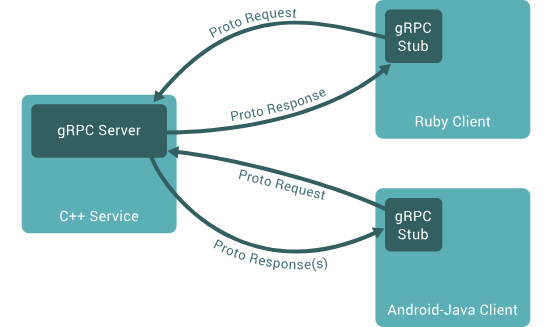

> By default, gRPC uses [**Protocol Buffers**](https://protobuf.dev/overview/), Google’s mature open source mechanism for serializing structured data (although it can be used with other data formats such as JSON).

In pratica, gRPC usa i *protocol buffer* (anche detti *protobuf*) come:
- **IDL** (Interface Definition Language) per definire l'interfaccia del servizio - generazione automatica di stub client e classi server astratte
- **formato di interscambio** di messaggi

Dalla documentazione:

> Protocol buffers provide a **serialization format for packets of typed, structured data** that are up to a few megabytes in size. The format is suitable for both ephemeral network traffic and long-term data storage. Protocol buffers can be extended with new information without invalidating existing data or requiring code to be updated.

> Protocol buffers are the most commonly-used data format at Google. They are used extensively in inter-server communications as well as for archival storage of data on disk. Protocol buffer messages and services are described by engineer-authored `.proto` files. The following shows an example message:

```proto
edition = "2023";
// commento su singola riga

/**
 * commento su più righe
 */

message Person {
  string name = 1;
  int32 id = 2;
  string email = 3;
}

```

Ad esempio, in `string name = 1`:
- `string` è il *field type*
- `name` è il ***field name***
- `1` è il `field tag`
  
```proto
field_type field_name = field_tag;
```

Altre caratteristiche principali di gRCP sono:
- **HTTP/2** per il trasporto - l'idea di base di gRPC è *trattare le RPC come riferimenti a oggetti HTTP/2*
- supporto per l'autenticazione, streaming bidirezionale e controllo del flusso
- supporto per comunicazione *bloccante* e *non bloccante*

#### Alcuni esempi di protocol buffer



```proto
// ProductInfo.proto
syntax = "proto3";
package ecommerce;
service ProductInfo {
rpc addProduct(Product) returns (ProductID);
rpc getProduct(ProductID) returns (Product);
}
message Product {
string id = 1;
string name = 2;
string description = 3;
}
message ProductID {
string value = 1;
}
```
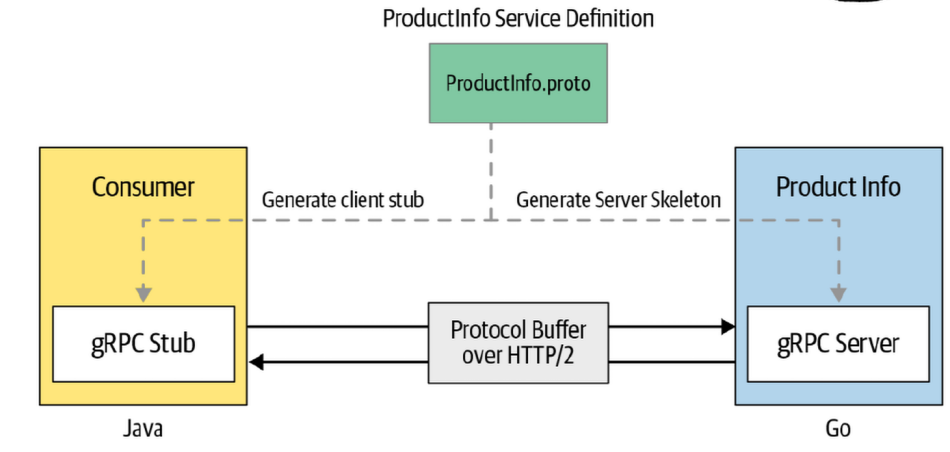

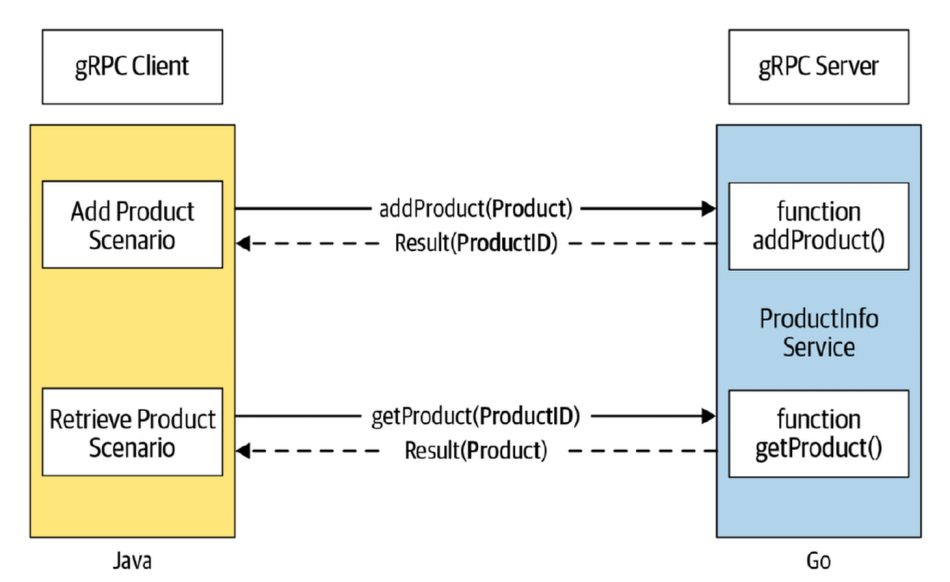

In relazione a questo esempio, il workflow sarebbe il seguente:

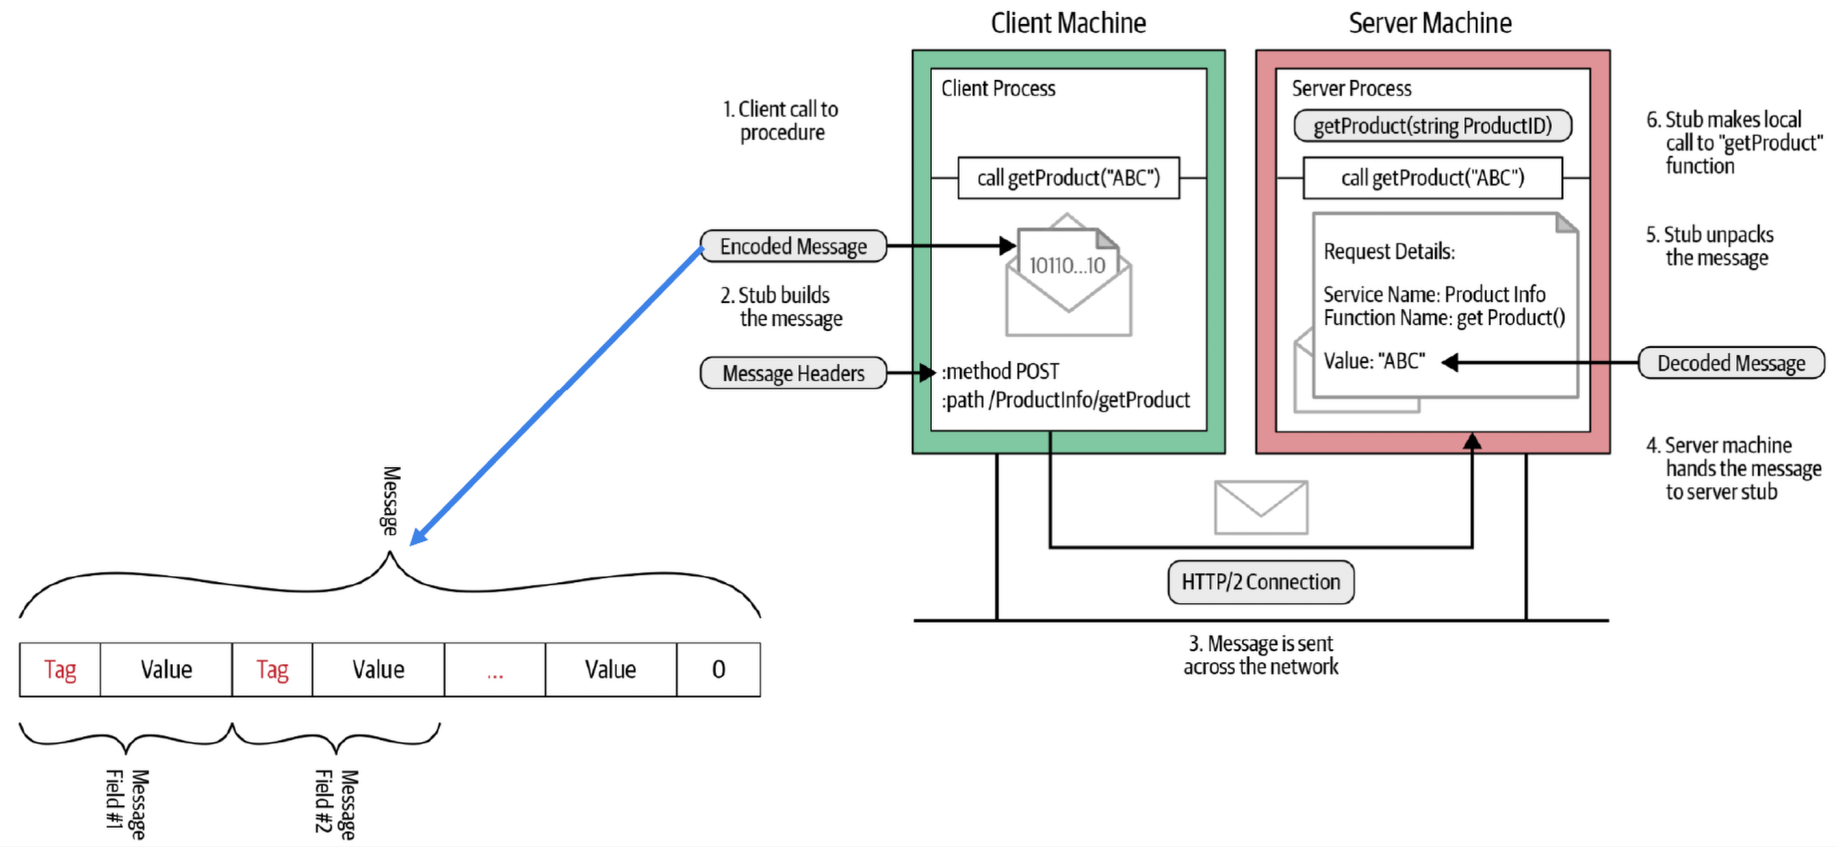

#### Compilazione del file `.proto` e i vari file generati

Il comando per compilare il file `.proto` e generare le varie classi (stub, skeleton, serializzare/deserializzare messaggi) è il seguente:

```bash
$ python -m grpc_tools.protoc -I. --python_out=. --pyi_out=. --grpc_python_out=. NOMESERVIZIO.proto
```
Questa compilazione genererà 2 file:
- `<NOMESERVIZIO>_pb2.py` - contiene le classi di messaggi del protocol buffer che si usano per serializzare / deserializzare i messaggi; è l'output del flag `--python_out`
- `<NOMESERVIZIO>_pb2_grpc.py` - contiene le classi del servizio gRPC; è l'output del flag `--grpc_python_out`

Dalla documentazione ufficiale:

> The gRPC generated code starts by importing the `grpc` package and the plain `_pb2` module, synthesized by protoc, which defines non-gRPC-specific code elements, like the classes corresponding to protocol buffers messages and descriptors used by reflection.

For each service `Foo` in the `.proto` file, three primary elements are generated:

- **Stub**: `FooStub` used by the client to connect to a gRPC service.
- **Servicer**: `FooServicer` used by the server to implement a gRPC service.
- **Registration Function**: `add_FooServicer_to_server` function used to register a servicer with a `grpc.Server` object.

Ad esempio, si consideri il file `helloworld/protos/helloworld.proto`:

```proto
syntax = "proto3";

package helloworld;

// The greeting service definition.
service Greeter {
  // Sends a greeting
  rpc SayHello (HelloRequest) returns (HelloReply) {}
  // Sends another greeting
  // rpc SayHelloAgain (HelloRequest) returns (HelloReply) {}
}

// The request message containing the user's name.
message HelloRequest {
  string name = 1;
}

// The response message containing the greetings
message HelloReply {
  string message = 1;
}

```

**Prima:**
```text
|── helloworld
    └── protos
        └── helloworld.proto
```

In [ ]:
! uv run python -m grpc_tools.protoc -I helloworld/protos --python_out=helloworld --pyi_out=helloworld --grpc_python_out=helloworld helloworld/protos/helloworld.proto

**Dopo:**
```text
└── helloworld
    ├── helloworld_pb2_grpc.py <-- 
    ├── helloworld_pb2.py <--
    ├── helloworld_pb2.pyi <--
    └── protos
        └── helloworld.proto
```

È interessante leggere `helloworld_pb2_grpc.GreeterStub`:

```python
self.SayHello = channel.unary_unary(
                '/helloworld.Greeter/SayHello',
                request_serializer=helloworld__pb2.HelloRequest.SerializeToString, # <-- la request viene serializzata (`SerializeToString`)
                response_deserializer=helloworld__pb2.HelloReply.FromString, # <-- la reponse viene de-serializzata (`FromString`)
                _registered_method=True)
```

In questo esempio, nei file `server.py` e `client.py` si è implementata la logica applicativa, mentre la comunicazione è responsabilità di `gRPC`. Prova a lanciare il server con il comando qui sotto, poi apri il terminale e lancia il client!

In [ ]:
! uv run python helloworld/server.py

#### Vari tipi di RPC
L'esempio sopra è un tipo di RPC semplice, in cui  il client invia una richiesta al server e attende una singola
risposta (cioè, unaria), come una normale chiamata di funzione. Esistono però altri tipi di RPC call in gRPC:
- **streaming lato server (*response-streaming RPC*)** - il client invia una richiesta al server e ottiene un flusso (*stream*) per leggere una sequenza di messaggi
  - il client leggerà dallo stream fincè non ci sono più messaggi
  - gRPC garantisce l'**ordinamento** dei messaggi al'interno di una singola chiamata RPC
  - la sintassi in `.proto` è `rpc Foo(...) returns (stream Bar) {}`
- **streaming lato client (*request-streaming RPC*)** - il client scrive una sequenza di messaggi e li invia al server, sempre utilizzando uno stream fornito
  - una volta terminata la scrittura dei messaggi, il client attende che il server li legga tutti e restituisca la risposta
  - gRPC garantisce l'**ordinamento** dei messaggi al'interno di una singola chiamata RPC
  - la sintassi in `.proto` è `rpc Foo(stream ...) returns (Bar) {}`
- ***bidirectional streaming RPC*** - entrambe le parti inviano una sequenza di messaggi utilizzando un flusso di lettura e scrittura
  - i due flussi operano indipendentemente, quindi client e server possono leggere / scrivere nell'ordine che preferiscono (e.g. leggo tutto e poi rispondo, oppure leggo, rispondo, leggo, rispondo o altre combinazioni)
  - l'ordine dei messaggi in ogni flusso viene mantenuto
  - la sintassi in `.proto` è `rcp Foo(stream ...) returns (stream ...)` {}

Si consideri il file `helloworld_streaming/protos/helloworld.protos`:

```proto
syntax = "proto3";

package helloworld_streaming;

// The greeting service definition.
service Greeter {
  // Sends a greeting, receive a stream (Streaming server)
  rpc SayHello_v1 (HelloRequest) returns (stream HelloReply) {}
  // Sends a stream of greetings, receive a single response (Streaming client)
  rpc SayHello_v2 (stream HelloRequest) returns (HelloReply) {}
  // Sends a stream of greetings, receive a stream (Bi-directional streaming)
  rpc SayHello_v3 (stream HelloRequest) returns (stream HelloReply) {}
}

// The request message containing the user's name.
message HelloRequest {
  string name = 1;
}

// The response message containing the greetings
message HelloReply {
  string message = 1;
}
```

**Prima:**
```text
└── helloworld_streaming
    └── protos
        └── helloworld.proto
```

In [ ]:
! OUT_DIR=helloworld_streaming && uv run python -m grpc_tools.protoc -I $OUT_DIR/protos --python_out=$OUT_DIR --pyi_out=$OUT_DIR --grpc_python_out=$OUT_DIR $OUT_DIR/protos/helloworld.proto

**Dopo**:
```text
└── helloworld_streaming
    ├── helloworld_pb2_grpc.py <--
    ├── helloworld_pb2.py <--
    ├── helloworld_pb2.pyi <--
    └── protos
        └── helloworld.proto
```

Si osservi in particolare come ogni RPC in `helloworld_pb2_grpc.GreeterStub` sia diverso:
```python
self.SayHello_v1 = channel.unary_stream( # <- Streaming lato server Client(Unary) <-> Server(Stream)
        '/helloworld.Greeter/SayHello_v1',
        request_serializer=helloworld__pb2.HelloRequest.SerializeToString,
        response_deserializer=helloworld__pb2.HelloReply.FromString,
        _registered_method=True)
self.SayHello_v2 = channel.stream_unary( # <- Streaming lato client Client(Stream) <-> Server(Unary)
        '/helloworld.Greeter/SayHello_v2',
        request_serializer=helloworld__pb2.HelloRequest.SerializeToString,
        response_deserializer=helloworld__pb2.HelloReply.FromString,
        _registered_method=True)
self.SayHello_v3 = channel.stream_stream( # <- Streaming bidirezionle Client(Stream) <-> Server(Stream)
        '/helloworld.Greeter/SayHello_v3',
        request_serializer=helloworld__pb2.HelloRequest.SerializeToString,
        response_deserializer=helloworld__pb2.HelloReply.FromString,
        _registered_method=True)
```
e come cambiano le firme delle funzioni in `helloworld_pb2_grpc.GreeterServicer`:

```python
    def SayHello_v1(self, request, context): # <-- Streaming lato server, quindi client manda semplice request
        """Sends a greeting, receive a stream (Streaming server)
        """
        context.set_code(grpc.StatusCode.UNIMPLEMENTED)
        context.set_details('Method not implemented!')
        raise NotImplementedError('Method not implemented!')

    def SayHello_v2(self, request_iterator, context): # <-- Streaming lato client, quindi client manda un `request_iterator`
        """Sends a stream of greetings, receive a single response (Streaming client)
        """
        context.set_code(grpc.StatusCode.UNIMPLEMENTED)
        context.set_details('Method not implemented!')
        raise NotImplementedError('Method not implemented!')

    def SayHello_v3(self, request_iterator, context):
        """Sends a stream of greetings, receive a stream (Bi-directional streaming)
        """
        context.set_code(grpc.StatusCode.UNIMPLEMENTED)
        context.set_details('Method not implemented!')
        raise NotImplementedError('Method not implemented!')
```
In particolare, un `request_iterator` sarà un `Generator` object.

#### Logica applicativa
Il client fa uso di questa funzione:

In [ ]:
import grpc
help(grpc.insecure_channel) # address deve essere str, non tupla!

mentre il server:

In [ ]:
import grpc
help(grpc.server)
help(grpc.Server.add_insecure_port)
help(grpc.Server.start)
help(grpc.Server.wait_for_termination)


---

> **Per la logica applicativa e il workflow, si consiglia lo schema `gRPC.drawio`**

---

**Nota:** dalla documentazione ufficiale di `add_insecure_port(address)`:

```text
add_insecure_port(address)

    Opens an insecure port for accepting RPCs.

    This method may only be called before starting the server.

    Parameters:

        address – The address for which to open a port. If the port is 0, or not specified in the address, then gRPC runtime will choose a port.
    Returns:

        An integer port on which server will accept RPC requests.
```
quindi la funzione può prendere anche `0` come porta e ne sceglierà una a runtime. In tal caso, *è opportuno salvare* (o meglio, mostrare) *il valore di ritorno* per capire **a quale porta connettere il client.**

Nella cartella `helloworld_streaming/`, nei file `server.py` e `client.py` si è implementata la logica applicativa, mentre la comunicazione è responsabilità di `gRPC`. Prova a lanciare il server con il comando qui sotto, poi apri il terminale e lancia il client!

In [ ]:
! uv run python helloworld_streaming/server.py